# 27 · GSE135779 · scRNA_seq · module–trait associations

Reads `expression.rds`, `modules.rds`, `metadata.rds`, and the GSE65391 end product `module_genes.csv`.
Writes the end products `module_traits.csv` and `clinical_dictionary.csv` in `data/run_artifacts/GSE135779/`.

**Samples:** the 33 children with SLE (as for GSE65391). A separate test uses all 44 children for
SLE against healthy.

**Traits**, from Supplementary Table 1b, named as in GSE65391 notebook 06 where the variable is the same:

| trait | source column | coding |
|---|---|---|
| sledai | SLEDAI | score |
| stage | SLEDAI | 0 none, 1 mild 1–5, 2 moderate 6–10, 3 high 11–19, 4 very high ≥ 20 |
| nephritis_any | Neph_all | 0/1 |
| nephritis_proliferative | Neph_class | 1 if the class includes III or IV (the classes GSE65391 calls Prolif), 0 otherwise |
| age | GEO age | years |
| female | Gender | 1 female |
| c3, c4 | C3, C4 | as recorded |
| wbc, neutrophil_count, lymphocyte_count, platelet_count | WBC, NEU_ABS, LYM_ABS, PLATELETS | as recorded |
| oral_steroids, mycophenolate, hydroxychloroquine | OS, MMF, Plaquenil | 0/1 |
| methotrexate | MTX | 0/1 (not recorded in GSE65391) |
| mdg | MDG | 0–3 (the authors' own grouping; not the same scale as GSE65391's mdg) |

Anti-dsDNA is recorded as a titer, in different units from GSE65391, and is not used.

**Eigengenes**, two families: **array modules** (each GSE65391 module's genes as measured here,
summarised by their first principal component, `WGCNA::moduleEigengenes`) and **own modules**
(notebook 25).

**Test.** Pearson r between eigengene and trait on the children where the trait is recorded; p from
`cor.test`; BH q within each family. **A finding** is q < 0.05.

In [1]:
if (!requireNamespace("WGCNA", quietly = TRUE)) install.packages("WGCNA", repos = "https://cloud.r-project.org")
suppressMessages(library(WGCNA))
source("../src/paths.R")
x    <- readRDS(art("GSE135779", "expression.rds"))
own  <- readRDS(art("GSE135779", "modules.rds"))
meta <- readRDS(art("GSE135779", "metadata.rds"))
mg   <- read.csv(art("GSE65391", "module_genes.csv"))
mg   <- mg[mg$gene %in% rownames(x$E), ]
sle  <- rownames(meta)[meta$sle == 1]
datExpr <- t(x$E[, sle])
ME_array <- moduleEigengenes(datExpr[, mg$gene], colors = mg$module)$eigengenes
ME_own   <- own$MEs[sle, colnames(own$MEs) != "MEgrey"]
m <- meta[sle, ]
table(Neph_class = m$Neph_class, Proliferative_Neph = m$Proliferative_Neph, useNA = "ifany")

          Proliferative_Neph
Neph_class  0  1 <NA>
      0     3  0   10
      2     1  0    4
      2,5   0  0    1
      2.5   0  0    2
      3     0  1    2
      3.5   0  1    0
      4     0  2    0
      4.5   0  0    1
      5     1  0    2
      <NA>  1  0    1

**Result.** `Proliferative_Neph` is missing for 20 of the 33 children, so proliferative nephritis is
derived from `Neph_class` (class III or IV), which is recorded for 31.

In [2]:
traits <- data.frame(
  sledai = m$SLEDAI,
  stage = as.numeric(cut(m$SLEDAI, c(-Inf, 0, 5, 10, 19, Inf))) - 1,
  nephritis_any = m$Neph_all,
  nephritis_proliferative = ifelse(is.na(m$Neph_class), NA, as.numeric(grepl("3|4", m$Neph_class))),
  age = m$age, female = as.numeric(m$Gender == "F"),
  c3 = m$C3, c4 = m$C4, wbc = m$WBC, neutrophil_count = m$NEU_ABS, lymphocyte_count = m$LYM_ABS,
  platelet_count = m$PLATELETS,
  oral_steroids = m$OS, mycophenolate = m$MMF, hydroxychloroquine = m$Plaquenil, methotrexate = m$MTX,
  mdg = m$MDG, row.names = sle)
data.frame(recorded = colSums(!is.na(traits)),
           summary = sapply(traits, function(v) if (all(v %in% c(0, 1, NA))) paste0(sum(v == 1, na.rm = TRUE), " of ", sum(!is.na(v)), " = 1")
                                                 else sprintf("median %.2f", median(v, na.rm = TRUE))))

,recorded,summary
,<dbl>,<chr>
sledai,31,median 4.00
stage,31,median 1.00
nephritis_any,33,18 of 33 = 1
nephritis_proliferative,31,7 of 31 = 1
age,33,median 16.00
female,33,30 of 33 = 1
c3,32,median 87.50
c4,32,median 11.95
wbc,32,median 5.85


In [3]:
test_family <- function(ME, family) {
  out <- do.call(rbind, lapply(colnames(ME), function(me) do.call(rbind, lapply(colnames(traits), function(tr) {
    ok <- !is.na(traits[[tr]]) & !is.na(ME[, me])
    if (length(unique(traits[ok, tr])) < 2) return(NULL)
    ct <- cor.test(ME[ok, me], traits[ok, tr])
    data.frame(family = family, module = sub("^ME", "", me), trait = tr, n = sum(ok), r = unname(ct$estimate), p = ct$p.value)
  }))))
  out$q <- p.adjust(out$p, "BH"); out
}
res_array <- test_family(ME_array, "array module")
res_own   <- test_family(ME_own, "own module")
c(array_tests = nrow(res_array), array_q_below_0.05 = sum(res_array$q < 0.05),
  own_tests = nrow(res_own), own_q_below_0.05 = sum(res_own$q < 0.05))
res_array[res_array$q < 0.05, c("module", "trait", "n", "r", "q")][order(res_array$q[res_array$q < 0.05]), ]
res_own[res_own$q < 0.05, c("module", "trait", "n", "r", "q")][order(res_own$q[res_own$q < 0.05]), ]

array_tests array_q_below_0.05          own_tests   own_q_below_0.05 
               272                 19                493                  8

,module,trait,n,r,q
,<chr>,<chr>,<int>,<dbl>,<dbl>
164,pink,lymphocyte_count,32,-0.7020888,0.002046131
113,lightcyan,lymphocyte_count,32,-0.6466004,0.008673809
44,brown,neutrophil_count,32,0.5859674,0.032804851
198,red,lymphocyte_count,32,0.5814767,0.032804851
11,black,lymphocyte_count,32,0.5608988,0.034130264
43,brown,wbc,32,0.5591631,0.034130264
109,lightcyan,c3,32,-0.5713625,0.034130264
249,turquoise,lymphocyte_count,32,0.5535356,0.034509089
9,black,wbc,32,0.5442903,0.036541237


,module,trait,n,r,q
,<chr>,<chr>,<int>,<dbl>,<dbl>
266,royalblue,lymphocyte_count,32,-0.6764067,0.01054857
316,midnightblue,neutrophil_count,32,-0.6415731,0.01868729
60,purple,wbc,32,0.6024343,0.03051244
61,purple,neutrophil_count,32,0.5928175,0.03051244
264,royalblue,wbc,32,-0.5907416,0.03051244
315,midnightblue,wbc,32,-0.5979968,0.03051244
399,yellow,c4,32,0.5784050,0.03699242
351,brown,lymphocyte_count,32,0.5656785,0.04563875


**Result.** Array modules: 19 of 272 tests with q < 0.05. The strongest:
- pink (interferon) with lymphocyte count, r = −0.70;
- lightcyan (neutrophil granule) with lymphocyte count, r = −0.65; with C3, r = −0.57; with C4, r = −0.54;
- brown (red cell) with neutrophil count, r = 0.59.

Own modules: 8 of 493, including royalblue (the interferon module here) with lymphocyte count, r = −0.68.
No module reaches q < 0.05 for SLEDAI, stage or nephritis.

The array-module table as a heatmap: Pearson r, * for q < 0.05.

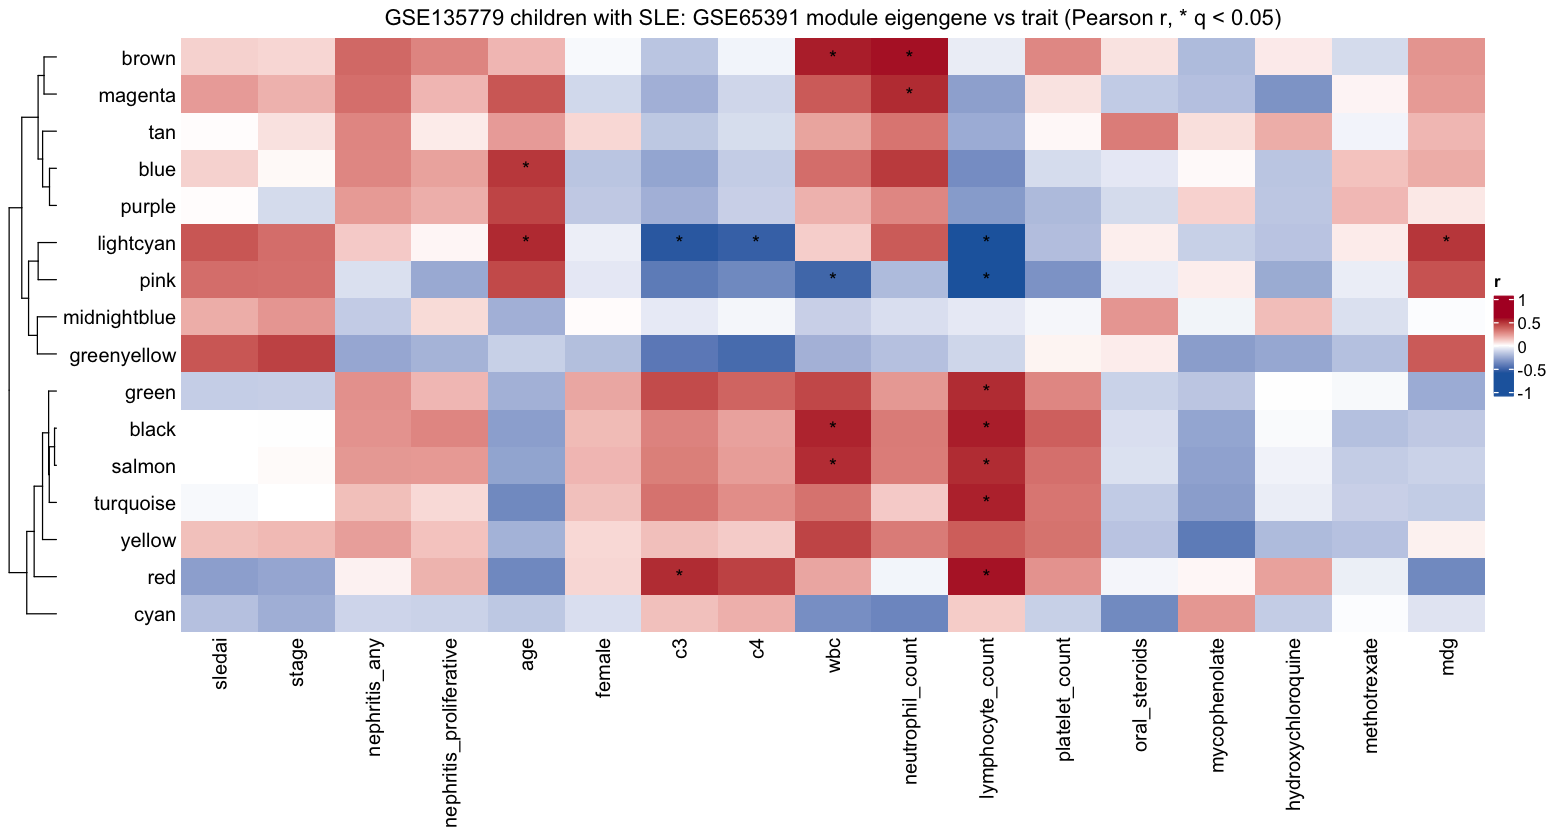

In [4]:
suppressMessages({library(ComplexHeatmap); library(circlize)})
R <- xtabs(r ~ module + trait, res_array)[, colnames(traits)]; Q <- xtabs(q ~ module + trait, res_array)[, colnames(traits)]
options(repr.plot.width = 13, repr.plot.height = 7)
Heatmap(unclass(R), name = "r", col = colorRamp2(c(-0.6, 0, 0.6), c("#2166AC", "white", "#B2182B")),
        cluster_columns = FALSE, row_names_side = "left",
        cell_fun = function(j, i, x, y, w, h, f) if (Q[i, j] < 0.05) grid.text("*", x, y),
        column_title = "GSE135779 children with SLE: GSE65391 module eigengene vs trait (Pearson r, * q < 0.05)")

**Test.** SLE against healthy, all 44 children: point-biserial r between each array-module eigengene
and `sle` (1 SLE, 0 healthy); BH q across modules.

In [5]:
all44 <- t(x$E)
ME44  <- moduleEigengenes(all44[, mg$gene], colors = mg$module)$eigengenes
sv <- do.call(rbind, lapply(colnames(ME44), function(me) {
  ct <- cor.test(ME44[, me], meta$sle); data.frame(family = "array module", module = sub("^ME", "", me), trait = "sle_vs_healthy",
                                                   n = nrow(meta), r = unname(ct$estimate), p = ct$p.value) }))
sv$q <- p.adjust(sv$p, "BH"); sv[order(sv$p), ]

,family,module,trait,n,r,p,q
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
10,array module,pink,sle_vs_healthy,44,0.57099264,5.176194e-05,0.0004863494
3,array module,brown,sle_vs_healthy,44,0.55536390,9.115827e-05,0.0004863494
7,array module,lightcyan,sle_vs_healthy,44,0.55535389,9.119052e-05,0.0004863494
15,array module,turquoise,sle_vs_healthy,44,-0.51775469,3.189134e-04,0.0012756536
5,array module,green,sle_vs_healthy,44,-0.49364899,6.612356e-04,0.0018313512
2,array module,blue,sle_vs_healthy,44,0.49234725,6.867567e-04,0.0018313512
8,array module,magenta,sle_vs_healthy,44,0.46056780,1.655287e-03,0.0037835126
11,array module,purple,sle_vs_healthy,44,0.44080948,2.745866e-03,0.0054917317
1,array module,black,sle_vs_healthy,44,-0.39217329,8.466035e-03,0.0150507280


**Result.** 13 of the 16 GSE65391 modules differ between SLE and healthy children at q < 0.05.
Higher in SLE: pink (interferon, r = 0.57), brown (red cell, r = 0.56), lightcyan (neutrophil
granule, r = 0.56), blue, magenta, purple. Lower in SLE: turquoise, green, black, salmon, yellow, red.

In [6]:
res <- rbind(res_array, res_own, sv)
res$fisher_z <- atanh(res$r); res$se <- 1 / sqrt(res$n - 3)
write.csv(res, art("GSE135779", "module_traits.csv"), row.names = FALSE)
dict <- data.frame(study = "GSE135779", trait = c(colnames(traits), "sle_vs_healthy"),
                   recorded = c(colSums(!is.na(traits)), nrow(meta)),
                   binary = c(sapply(traits, function(v) all(v %in% c(0, 1, NA))), TRUE), row.names = NULL)
write.csv(dict, art("GSE135779", "clinical_dictionary.csv"), row.names = FALSE)
dict

study,trait,recorded,binary
<chr>,<chr>,<dbl>,<lgl>
GSE135779,sledai,31,FALSE
GSE135779,stage,31,FALSE
GSE135779,nephritis_any,33,TRUE
GSE135779,nephritis_proliferative,31,TRUE
GSE135779,age,33,FALSE
GSE135779,female,33,TRUE
GSE135779,c3,32,FALSE
GSE135779,c4,32,FALSE
GSE135779,wbc,32,FALSE
